In [1]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

In [125]:
# All the input paths
inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
ops_path = inspire_path / "operations.csv"
labs_path = inspire_path / "labs.csv"
vitals_path = inspire_path / "vitals.csv"
ward_vitals_path = inspire_path / "ward_vitals.csv"
combined_path = inspire_path / "combined_data.csv"
combined_cleaned_path = inspire_path / "combined_cleaned_data.csv"
pca_path = inspire_path / "pca_data.csv"
diagnosis_path = inspire_path / "diagnosis.csv"

preopdata_file = "/home/server/Projects/data/AKI/preop_data.csv"
preopdata_file_nidhir = "/home/server/Projects/data/AKI/preop_data_nidhir.csv"
aki_data = "/home/server/Projects/data/AKI/aki_data.csv"

# Output path
output_path = Path("/home/server/Projects/data/AKI")

In [15]:
df_labs = pd.read_csv(labs_path)

In [11]:
# Read the necessary csv files for the data
df_vitals = pd.read_csv(vitals_path)

In [12]:
# Read the necessary csv files for the data
df_preop = pd.read_csv(preopdata_file)

In [13]:
df_vitals

,op_id,subject_id,chart_time,item_name,value
0,435959808,181409183,1985,minvol,4.4
1,435959808,181409183,1985,vt,512.0
2,435959808,181409183,1985,rr,9.0
3,435959808,181409183,1985,pip,23.0
4,435959808,181409183,2005,minvol,4.4
...,...,...,...,...,...
66127935,447098707,159399111,1511530,nibp_dbp,92.0
66127936,447098707,159399111,1511530,nibp_mbp,119.0
66127937,447098707,159399111,1511530,spo2,100.0
66127938,447098707,159399111,1511535,hr,78.0


In [14]:
df_preop

,op_id,subject_id,age,sex,height,weight,asa,emop,opstart_time,opend_time,inhosp_death_time,allcause_death_time,BSA,BMI,booking_case_length,num_card_events,last_preop_scr,min_preop_scr
0,484069807,178742874,30,F,155.0,50.0,NaN,1,1140.0,1230.0,NaN,NaN,1.467235,20.811655,135.0,0,0.80,0.80
1,446270725,158995752,70,M,170.0,45.0,NaN,1,1370.0,1540.0,69860.0,106560.0,1.457738,15.570934,210.0,0,1.05,0.98
2,406892271,108553242,50,F,165.0,70.0,NaN,1,62200.0,62380.0,NaN,718560.0,1.791182,25.711662,230.0,0,0.98,0.74
3,478413008,133278262,35,F,NaN,55.0,NaN,1,230.0,330.0,NaN,NaN,NaN,NaN,130.0,0,0.71,0.71
4,468516791,116924034,45,F,150.0,45.0,1.0,0,17970.0,18070.0,NaN,NaN,1.369306,20.000000,135.0,0,0.71,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130955,449124488,138484174,50,F,160.0,60.0,2.0,0,5000410.0,5000570.0,NaN,NaN,1.632993,23.437500,190.0,0,0.71,0.58
130956,461252752,126772283,70,F,160.0,55.0,2.0,0,3370.0,3430.0,NaN,NaN,1.563472,21.484375,85.0,0,0.68,0.68
130957,471834474,144363433,65,F,150.0,50.0,2.0,0,3610.0,3665.0,NaN,NaN,1.443376,22.222222,80.0,0,0.65,0.61
130958,419787421,195835964,85,M,170.0,75.0,4.0,0,13815.0,13945.0,NaN,613440.0,1.881932,25.951557,175.0,1,0.65,0.65


In [16]:
df_labs

,subject_id,chart_time,item_name,value
0,133338290,86155,total_protein,6.9
1,133338290,86155,sodium,140.0
2,133338290,86155,potassium,4.4
3,133338290,86155,platelet,152.0
4,133338290,93150,glucose,120.0
...,...,...,...,...
19503330,155658270,35270,hb,15.0
19503331,155658270,35270,hct,44.1
19503332,155658270,35270,platelet,245.0
19503333,155658270,35270,seg,79.9


In [21]:
df_ops = pd.read_csv(ops_path)

In [73]:
df_ops[df_ops["antype"] == "General"]

,op_id,subject_id,hadm_id,case_id,opdate,age,sex,weight,height,race,...,admission_time,discharge_time,anstart_time,anend_time,cpbon_time,cpboff_time,icuin_time,icuout_time,inhosp_death_time,allcause_death_time
8463,437709174,100002094,290346554,NaN,2880,30,F,70.0,160.0,Asian,...,0,11515,3365.0,3570.0,NaN,NaN,3590.0,6525.0,NaN,NaN
34254,417666664,100002234,244112306,NaN,1440,45,M,80.0,180.0,Asian,...,0,8635,1930.0,2415.0,NaN,NaN,NaN,NaN,NaN,NaN
109885,415308940,100002413,273121428,-23650.0,1440,45,M,55.0,165.0,Asian,...,0,4315,2040.0,2060.0,NaN,NaN,NaN,NaN,NaN,NaN
13408,411077767,100004062,251793067,NaN,165600,85,M,50.0,170.0,Asian,...,0,306715,166505.0,166585.0,NaN,NaN,NaN,NaN,NaN,868320.0
52468,464232551,100010304,212882335,NaN,0,50,F,70.0,160.0,Asian,...,0,21595,400.0,495.0,NaN,NaN,515.0,6660.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39070,419379320,199997812,231451559,NaN,1440,65,M,55.0,175.0,Asian,...,0,4315,1910.0,1990.0,NaN,NaN,NaN,NaN,NaN,NaN
94144,402255444,199998113,247105308,14916.0,169920,60,M,75.0,170.0,Asian,...,167040,188635,170525.0,170775.0,NaN,NaN,NaN,NaN,NaN,2207520.0
68156,426862691,199998553,222032154,NaN,1440,75,M,55.0,165.0,Asian,...,0,5755,2385.0,2465.0,NaN,NaN,NaN,NaN,NaN,NaN
8656,439399659,199999332,278532625,NaN,1440,65,M,60.0,155.0,Asian,...,0,10075,2380.0,2765.0,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df_preop

,op_id,subject_id,age,sex,height,weight,asa,emop,opstart_time,opend_time,inhosp_death_time,allcause_death_time,BSA,BMI,booking_case_length,num_card_events,last_preop_scr,min_preop_scr,op_len
0,484069807,178742874,30,F,155.0,50.0,NaN,1,1140.0,1230.0,NaN,NaN,1.467235,20.811655,135.0,0,0.80,0.80,90.0
1,446270725,158995752,70,M,170.0,45.0,NaN,1,1370.0,1540.0,69860.0,106560.0,1.457738,15.570934,210.0,0,1.05,0.98,170.0
2,406892271,108553242,50,F,165.0,70.0,NaN,1,62200.0,62380.0,NaN,718560.0,1.791182,25.711662,230.0,0,0.98,0.74,180.0
3,478413008,133278262,35,F,NaN,55.0,NaN,1,230.0,330.0,NaN,NaN,NaN,NaN,130.0,0,0.71,0.71,100.0
4,468516791,116924034,45,F,150.0,45.0,1.0,0,17970.0,18070.0,NaN,NaN,1.369306,20.000000,135.0,0,0.71,0.71,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130955,449124488,138484174,50,F,160.0,60.0,2.0,0,5000410.0,5000570.0,NaN,NaN,1.632993,23.437500,190.0,0,0.71,0.58,160.0
130956,461252752,126772283,70,F,160.0,55.0,2.0,0,3370.0,3430.0,NaN,NaN,1.563472,21.484375,85.0,0,0.68,0.68,60.0
130957,471834474,144363433,65,F,150.0,50.0,2.0,0,3610.0,3665.0,NaN,NaN,1.443376,22.222222,80.0,0,0.65,0.61,55.0
130958,419787421,195835964,85,M,170.0,75.0,4.0,0,13815.0,13945.0,NaN,613440.0,1.881932,25.951557,175.0,1,0.65,0.65,130.0


In [91]:
prefixes_to_exclude = ["10", "0TY", "B50", "B51"]
mask = df_ops["icd10_pcs"].astype(str).str.startswith(tuple(prefixes_to_exclude))
ops_to_exclude = df_ops.loc[mask, "op_id"]
df_preop = df_preop[~df_preop["op_id"].isin(ops_to_exclude)]

In [96]:
df_preop["aki"] = df_preop["postop_creatinine"] - df_preop["preop_creatinine"]

In [124]:
df_preop[df_preop["aki"] < 0]

,Unnamed: 0,op_id,subject_id,age,sex,height,weight,asa,emop,opstart_time,...,preop_aptt,preop_calcium,preop_bun,preop_ast,preop_crp,preop_hb,preop_hct,preop_seg,postop_creatinine,aki
3,4,490288058,143981214,75,M,NaN,NaN,3.0,1,65.0,...,32.3,8.7,36.0,14.0,4.58,12.2,33.5,73.7,1.69,-1.35
4,5,474826299,122791000,50,F,160.0,50.0,3.0,1,70.0,...,24.0,8.2,12.0,20.0,0.06,11.6,35.2,86.8,0.47,-0.30
5,7,485521242,101569193,45,M,175.0,65.0,1.0,1,75.0,...,24.0,9.0,15.0,31.0,0.06,14.2,44.1,44.0,0.65,-0.19
9,13,438008606,180985602,65,F,155.0,40.0,1.0,1,100.0,...,29.6,8.9,21.0,23.0,2.93,9.8,39.1,89.7,0.53,-0.05
10,14,464762521,170243073,55,M,180.0,65.0,2.0,1,100.0,...,30.1,9.6,15.0,15.0,1.14,13.7,33.5,69.6,0.77,-0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51361,52710,438594426,173535294,50,M,165.0,75.0,2.0,0,5031870.0,...,31.2,9.6,9.0,28.0,0.06,14.2,36.1,49.5,0.80,-0.12
51362,52711,476980521,138477344,65,F,165.0,60.0,2.0,0,5055170.0,...,27.2,9.8,21.0,19.0,0.02,13.2,40.4,58.6,0.61,-0.19
51365,52714,485921156,132778234,70,F,155.0,65.0,2.0,0,5081095.0,...,32.3,8.9,21.0,19.0,0.19,12.9,36.1,49.5,0.65,-0.09
51366,52715,452652040,117366461,70,M,175.0,70.0,2.0,0,5089780.0,...,NaN,9.8,18.0,31.0,0.06,15.0,40.4,63.2,0.92,-0.06


In [126]:
df_preop.to_csv(preopdata_file_nidhir)

In [112]:
df_preop = pd.read_csv(preopdata_file_nidhir)

In [39]:
item_names = [
    "total_protein",
    "sodium",
    "potassium",
    "platelet",
    "glucose",
    "wbc",
    "alt",
    "chloride",
    "lymphocyte",
    "phosphorus",
    "albumin",
    "fibrinogen",
    "creatinine",
    "ptinr",
    "total_bilirubin",
    "alp",
    "aptt",
    "calcium",
    "bun",
    "ast",
    "crp",
    "hb",
    "hct",
    "seg"
]

In [109]:
for item_name in item_names:
    df_preop = pd.merge_asof(df_preop.sort_values('opstart_time'), 
                    df_labs.loc[df_labs['item_name'] == item_name].sort_values('chart_time'), # grab rows w the item name we want and sort by chart_time
                    left_on='opstart_time', right_on='chart_time', by='subject_id',           # chooses row in df_labs w greatest chart_time that is still less than opstart_time and matches subject_id
                    tolerance=90 * 24 * 60, suffixes=('', '_'))                               # 90 day tolerance
    df_preop.drop(columns=['chart_time', 'item_name'], inplace=True)
    df_preop.rename(columns={'value':f'preop_{item_name}'}, inplace=True)

In [110]:
df_preop

,op_id,subject_id,age,sex,height,weight,asa,emop,opstart_time,opend_time,...,preop_total_bilirubin,preop_alp,preop_aptt,preop_calcium,preop_bun,preop_ast,preop_crp,preop_hb,preop_hct,preop_seg
0,490288058,143981214,75,M,NaN,NaN,3.0,1,65.0,430.0,...,0.4,71.0,32.3,8.7,36.0,14.0,4.58,12.2,33.5,73.7
1,403543518,164935053,45,M,180.0,65.0,1.0,1,65.0,300.0,...,0.8,86.0,25.1,9.3,18.0,108.0,0.19,14.2,40.4,92.0
2,412710661,192113673,55,M,170.0,60.0,2.0,1,80.0,175.0,...,0.8,75.0,30.1,9.1,21.0,31.0,0.19,15.0,40.4,75.7
3,457191636,166309260,75,F,160.0,55.0,3.0,1,85.0,170.0,...,1.2,55.0,25.1,8.9,29.0,21.0,8.30,11.3,31.0,86.8
4,438008606,180985602,65,F,155.0,40.0,1.0,1,100.0,280.0,...,0.7,80.0,29.6,8.9,21.0,23.0,2.93,9.8,39.1,89.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23564,408810006,199346252,65,M,165.0,55.0,2.0,0,4941500.0,4941645.0,...,0.3,86.0,25.1,8.8,17.0,31.0,0.77,10.7,28.0,63.2
23565,418309501,121440121,80,M,165.0,65.0,2.0,0,4963000.0,4963055.0,...,0.5,71.0,27.9,8.7,18.0,23.0,NaN,11.0,31.9,53.1
23566,438594426,173535294,50,M,165.0,75.0,2.0,0,5031870.0,5032095.0,...,0.4,49.0,31.2,9.6,9.0,28.0,0.06,14.2,36.1,49.5
23567,409353759,157622470,65,M,160.0,60.0,2.0,0,5065155.0,5065285.0,...,0.4,71.0,28.5,9.2,17.0,31.0,0.01,15.0,44.1,65.4


In [111]:
df_creatinine = df_labs[df_labs['item_name'] == 'creatinine']
df_merge = pd.merge(df_preop, df_creatinine, on='subject_id', suffixes=('_preop', '_lab'))
df_merge_filtered = df_merge[
    (df_merge['chart_time'] > df_merge['opend_time']) &
    (df_merge['chart_time'] < (df_merge['opend_time'] + 48 * 60))
]
max_creatinine = (
    df_merge_filtered.groupby(['subject_id', 'op_id'])['value']
    .max()
    .reset_index()
    .rename(columns={'value': 'postop_creatinine'})
)

In [62]:
df_preop = pd.merge(df_preop, max_creatinine, on=['subject_id', 'op_id'], how='inner')

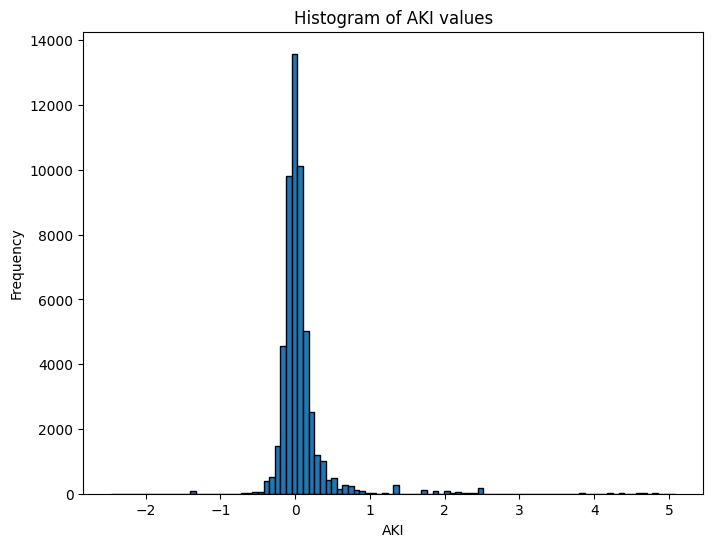

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(df_preop["aki"], bins=100, edgecolor="black")  # You can adjust the number of bins as needed
plt.xlabel("AKI")
plt.ylabel("Frequency")
plt.title("Histogram of AKI values")
plt.show()

In [151]:
df_preop = pd.read_csv(aki_data)

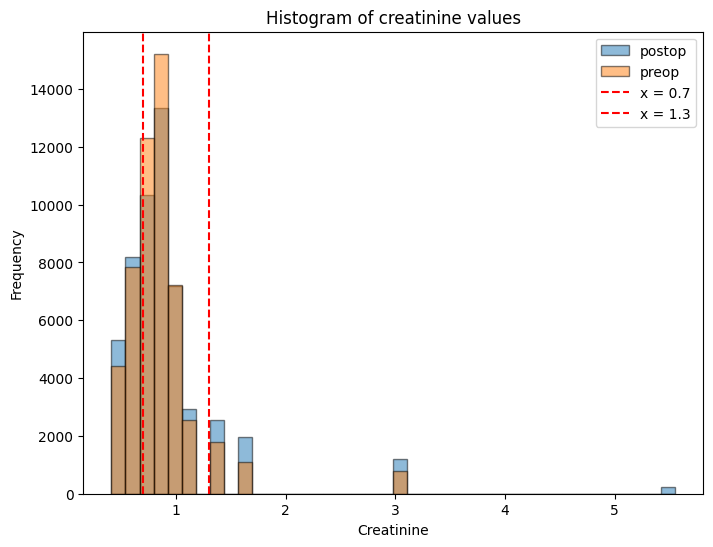

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
min_val = min(df_preop["postop_creatinine"].min(), df_preop["preop_creatinine"].min())
max_val = max(df_preop["postop_creatinine"].max(), df_preop["preop_creatinine"].max())
bin_edges = np.linspace(min_val, max_val, 41)
plt.hist(df_preop["postop_creatinine"], bins=bin_edges, edgecolor="black", alpha=0.5, label="postop")
plt.hist(df_preop["preop_creatinine"], bins=bin_edges, edgecolor="black", alpha=0.5, label="preop")
plt.axvline(x=0.7, color='red', linestyle='--', label='x = 0.7')
plt.axvline(x=1.3, color='red', linestyle='--', label='x = 1.3')
plt.xlabel("Creatinine")
plt.ylabel("Frequency")
plt.title("Histogram of creatinine values")
plt.legend()
plt.show()

In [158]:
df_preop["op_len"].mean()

178.09540959352125